In [1]:
import requests
import pandas as pd
from typing import Final
from blocksnet.enums import LandUse


## Пример загрузки потенциала проекта из бд

In [2]:
URBAN_API = "https://urban-api.idu.kanootoko.org/api/v1"

#211
#198
#124
#335

id = 198

scenario_indicators_response = requests.get(
    f"{URBAN_API}/scenarios/{id}/indicators_values", verify=False
)
if scenario_indicators_response.status_code != 200:
    raise Exception("Ошибка при получении индикаторов по сценарию")

scenario_indicators = scenario_indicators_response.json()

indicator_attributes = {
    indicator['indicator']['name_full']: indicator['value']
    for indicator in scenario_indicators
}

LAND_USE_RULES: Final[dict[str, LandUse]] = {
    "Потенциал развития жилой застройки": LandUse.RESIDENTIAL,
    "Потенциал развития застройки общественно-деловой зоны": LandUse.BUSINESS,
    "Потенциал развития застройки рекреационной зоны": LandUse.RECREATION,
    "Потенциал развития застройки зоны специального назначения": LandUse.SPECIAL,
    "Потенциал развития застройки промышленной зоны": LandUse.INDUSTRIAL,
    "Потенциал развития застройки сельскохозяйственной зоны": LandUse.AGRICULTURE,
    "Потенциал развития застройки транспортной зоны": LandUse.TRANSPORT,
}

records: list[dict[str, object]] = []
for indicator_name, land_use in LAND_USE_RULES.items():
    potential = indicator_attributes.get(indicator_name)
    if potential is None:
        continue
    records.append({
        'land_use': land_use,
        'potential': potential,
    })

base_df = pd.DataFrame(records).reset_index(drop=True)
base_df

base_df.to_csv("./data/land_use_potentials.csv", index=False)


/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'urban-api.idu.kanootoko.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [16]:
from urbanomy.methods.investment_potential import prepare_investment_input
scenario_blocks = pd.read_pickle('./data/blocks_with_price_test.pickle').to_crs(32636)
scenario_blocks = scenario_blocks.loc[scenario_blocks['is_scn'] == True].copy()

potential_df = pd.read_csv("./data/land_use_potentials.csv")

investment_input = prepare_investment_input(
    gdf = scenario_blocks,
    project_potential = potential_df,
)



2025-10-28 18:34:03.177 | WARNING  | urbanomy.utils.investment_input:_prepare_with_base:344 - prepare_investment_input: dropped 3 of 70 scenario polygons due to missing land-use after normalisation.


In [17]:
investment_input.head()


,land_use,price_pred,site_area,living_area,non_living_area,build_floor_area,share,ip_value
0,LandUse.AGRICULTURE,3.132176e+08,202399.732193,0.000000,12550.410318,12550.410318,0.918180,3.0
1,LandUse.BUSINESS,3.488025e+08,201529.493481,0.000000,40777.536145,40777.536145,0.938081,2.0
2,LandUse.TRANSPORT,2.232646e+08,164663.859830,0.000000,24985.649917,24985.649917,0.891381,4.0
3,LandUse.RESIDENTIAL,7.195687e+08,161571.832511,29356.900162,43211.792478,72568.692640,0.934862,0.0
4,LandUse.RESIDENTIAL,4.938179e+04,49.926816,0.678864,1.491125,2.169989,0.132440,0.0


## Инвевстиционная привлекательность

In [18]:
from blocksnet.enums import LandUse

benchmarks_demo = {
    LandUse.RESIDENTIAL: {
        "cost_build": 45_000,
        "price_sale": 110_000,
        "construction_years": 3,
        "sale_years": 3,
        "opex_rate": 800,
    },
    LandUse.BUSINESS: {
        "cost_build": 55_000,
        "rent_annual": 25_000,
        "rent_years": 12,
        "construction_years": 4,
        "opex_rate": 1_300,
    },
    LandUse.RECREATION: {
        "cost_build": 20_000,
        "rent_annual": 8_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_000,
    },
    LandUse.SPECIAL: {
        "cost_build": 35_000,
        "rent_annual": 11_000,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_500,
    },
    LandUse.INDUSTRIAL: {
        "cost_build": 38_000,
        "rent_annual": 14_800,
        "rent_years": 12,
        "construction_years": 3,
        "opex_rate": 700,
    },
    LandUse.AGRICULTURE: {
        "cost_build": 25_000,
        "rent_annual": 6_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 300,
    },
    LandUse.TRANSPORT: {
        "cost_build": 18_000,
        "rent_annual": 8_200,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 600,
    },
}




In [19]:
from urbanomy.methods.investment_potential import InvestmentAttractivenessAnalyzer

an = InvestmentAttractivenessAnalyzer(benchmarks=benchmarks_demo)
summary = an.calculate_investment_metrics(investment_input, discount_rate=0.18)
summary


Project totals:
 • Land area:          5,759,857.12
 • Built area:         1,426,481.21
 • Land cost:          10,154,719,247.52
 • Construction cost:  54,162,061,333.49
 • Investment need:    64,316,780,581.00
 • Spatial potential:  3.13
 • Project NPV:        4,998,138,511.57
 • Project IRR:        0.20
 • Project ROI:        5.73
 • Project PP (yrs):   12.23
 • Project EI:         58.41
 • Project INV score:  66.65


,land_use,land_area,built_area,land_cost,construction_cost,investment_need,NPV,IRR,ROI,PP_years,EI,spatial_potential,INV
0,LandUse.AGRICULTURE,202399.73,12550.41,3.132176e+08,3.137603e+08,6.269778e+08,-3.214205e+08,0.06,2.05,NaN,0.00,3.0,31.07
1,LandUse.BUSINESS,201529.49,40777.54,3.488025e+08,2.242764e+09,2.591567e+09,5.066266e+08,0.22,10.07,11.23,65.99,2.0,59.36
2,LandUse.TRANSPORT,164663.86,24985.65,2.232646e+08,4.497417e+08,6.730063e+08,5.106398e+06,0.18,5.93,17.49,1.90,4.0,42.54
3,LandUse.RESIDENTIAL,161571.83,72568.69,7.195687e+08,3.265591e+09,3.985160e+09,5.519951e+08,0.24,3.11,5.51,72.68,0.0,42.57
4,LandUse.RESIDENTIAL,49.93,2.17,4.938179e+04,9.764950e+04,1.470313e+05,-1.135879e+04,0.15,2.06,NaN,0.00,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,LandUse.BUSINESS,606.98,203.64,2.234950e+06,1.120008e+07,1.343503e+07,2.956564e+06,0.22,9.83,10.92,19.01,2.0,31.85
63,LandUse.AGRICULTURE,2.67,NaN,1.541350e+04,NaN,1.541350e+04,-1.196046e+04,0.15,5.41,NaN,0.00,3.0,31.07
64,LandUse.TRANSPORT,4307.66,688.58,6.684065e+06,1.239437e+07,1.907843e+07,-3.196150e+03,0.18,5.79,NaN,0.00,4.0,41.43
65,LandUse.BUSINESS,61.63,13.49,1.987425e+04,7.417990e+05,7.616732e+05,3.239680e+05,0.27,15.97,9.00,35.65,2.0,41.60


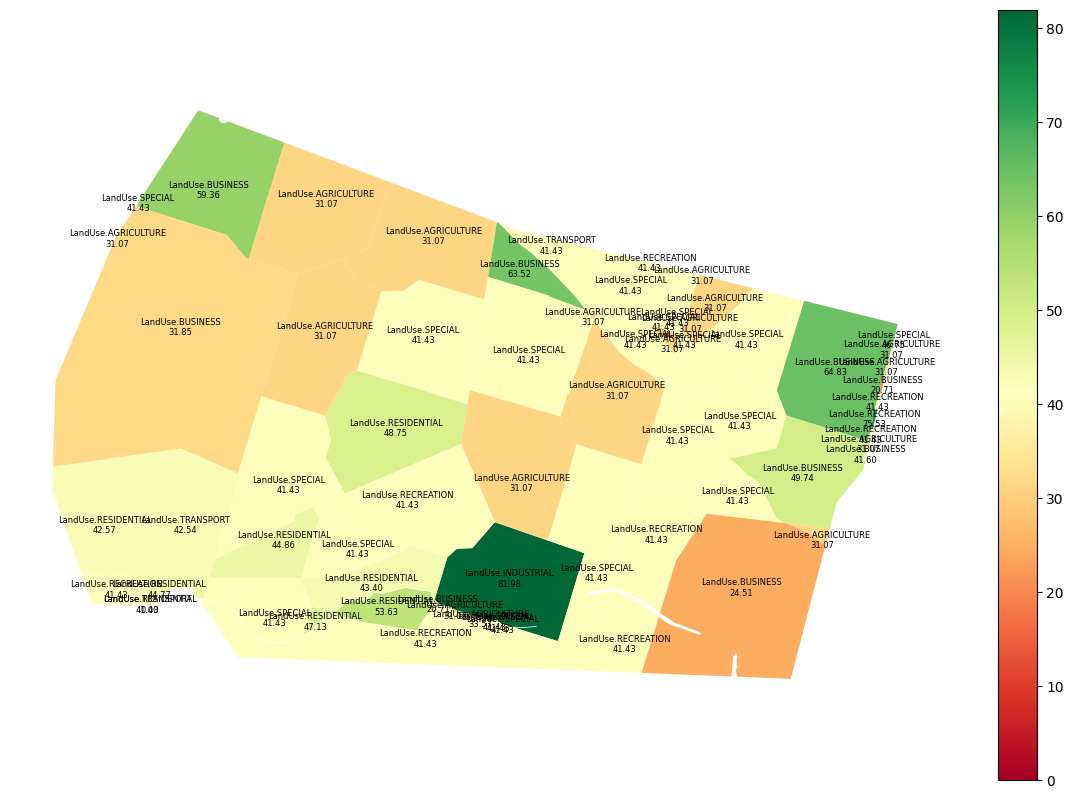

In [21]:
scn = scenario_blocks[['geometry']].join(summary)
column = 'INV'

ax = scn.plot(column=column, cmap='RdYlGn', legend=True, figsize=(15, 10))
for _, row in scn.dropna(subset=[column]).iterrows():
    x, y = row.geometry.representative_point().coords[0]
    ax.text(
        x,
        y,
        f"{row.land_use}\n{row[column]:.2f}",
        ha="center",
        va="center",
        fontsize=6,
        color="black",
    )

ax.set_axis_off()

In [9]:
scn.to_file('./data/blocks_investment.geojson', driver='GeoJSON')